In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'


In [2]:
 
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata.txt'
# Generate loop_info DataFrame

In [3]:
df_ms = pd.read_csv('./tables/linear_meltsensetivity.csv')
df_m2100 = pd.read_csv('./tables/averegeshelfmelt_2100.csv')
df_m2200 = pd.read_csv('./tables/averegeshelfmelt_2200.csv')
df_m2300 = pd.read_csv('./tables/averegeshelfmelt_2300.csv')


df_bmb2100 = pd.read_csv('./tables/totalshelfmelt_2100.csv')
df_bmb2200 = pd.read_csv('./tables/totalshelfmelt_2200.csv')
df_bmb2300 = pd.read_csv('./tables/totalshelfmelt_2300.csv')
                         


In [4]:
df_ms_model =df_ms.groupby(Model)

NameError: name 'Model' is not defined

In [5]:
df_ms

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,sector_10,sector_11,sector_12,sector_13,sector_14,sector_15,sector_16,sector_17,sector_18,AIS
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,3.828354,4.737837,5.928868,10.960910,4.604794,4.253669,5.779955,...,3.980752,4.940637,2.266156,2.509810,5.143798,4.424815,1.819057,1.814007,3.587276,4.821564
1,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,2.575912,1.436848,3.183263,2.854980,2.045962,0.725136,7.746842,...,2.717426,1.718347,11.416173,2.826694,6.588572,3.685268,0.975222,1.844895,3.220921,1.604816
2,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,15.213428,7.991450,13.685423,19.936638,9.877652,8.011056,9.118060,...,11.230654,9.695245,4.910368,10.117559,13.772524,11.279135,4.072268,8.231542,14.900852,10.744328
3,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,10.482246,9.450993,11.107289,16.571698,9.505661,7.740722,8.445124,...,10.069479,8.407779,5.394788,11.306524,11.694859,9.649061,4.152837,5.506176,11.865219,9.892176
4,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,11.551301,9.888853,11.404010,19.010057,8.634844,8.495505,9.084143,...,9.769269,7.655452,4.817216,10.372790,12.643937,10.417260,3.992109,5.867386,11.228245,12.432808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,expAE05,VUW_PISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,14.037853,2.708174,-0.231907,17.333194,10.440459,-0.572498,11.797057,...,-0.214472,2.383788,0.989386,2.271269,2.497107,1.472659,0.420629,0.576382,3.507298,4.088513
140,expAE05,VUW_PISM2_s1,/Volumes/CrucialX8/computing/data/antarctica/i...,18.333862,3.171366,-0.024971,16.217655,10.766359,-0.568770,12.395121,...,-0.203914,2.503227,0.873010,2.562283,2.793100,1.498977,0.525888,0.581310,3.799294,4.012023
141,expAE05,VUW_PISM2_s2,/Volumes/CrucialX8/computing/data/antarctica/i...,13.051684,2.254861,-0.221538,18.437352,10.355914,-0.477487,10.881982,...,-0.291718,2.396920,1.130295,1.953058,2.408528,1.435995,0.423175,0.577036,2.737886,4.382281
142,expAE05,VUW_PISM2_s3,/Volumes/CrucialX8/computing/data/antarctica/i...,13.939051,2.233008,-0.119592,12.748279,10.583776,-0.492497,10.384902,...,-0.231039,2.234349,1.120108,2.149874,2.465810,1.257831,0.459709,0.622817,2.506062,2.975869


In [6]:
grouped = df_ms.groupby('Model')

In [7]:
Models = df_ms[df_ms['Experiment']== 'expAE02'].Model

In [8]:
Models.index

Int64Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
            17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
            34, 35],
           dtype='int64')

Text(0, 0.5, 'melt sens.')

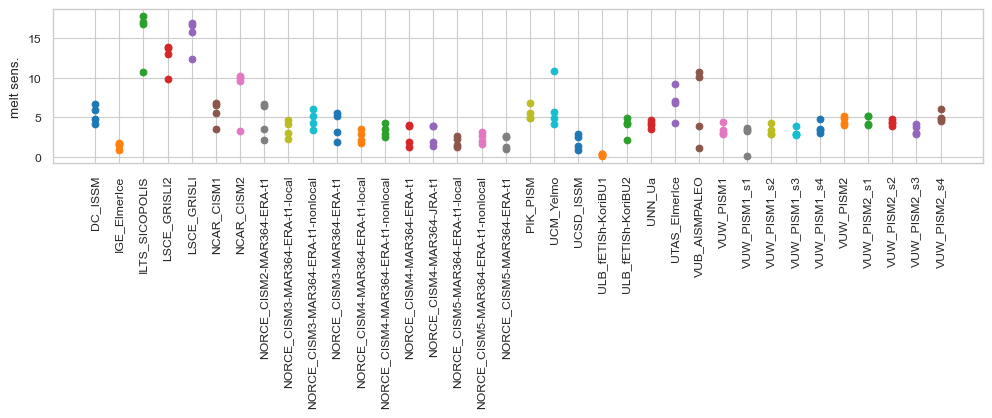

In [9]:
f,ax = plt.subplots(1,1, figsize = (12,2), sharex = True)
for i,Mod in enumerate(Models):
    ax.scatter([i,i,i,i],df_ms[df_ms['Model']== Mod].AIS.values)
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
ax.set_ylabel('melt sens.')
    
    


## The linear melt sensetivity  spreads for the four different experimets. Ideally they would be the same , this is also true for different sectors

Text(0, 0.5, 'melt sens.')

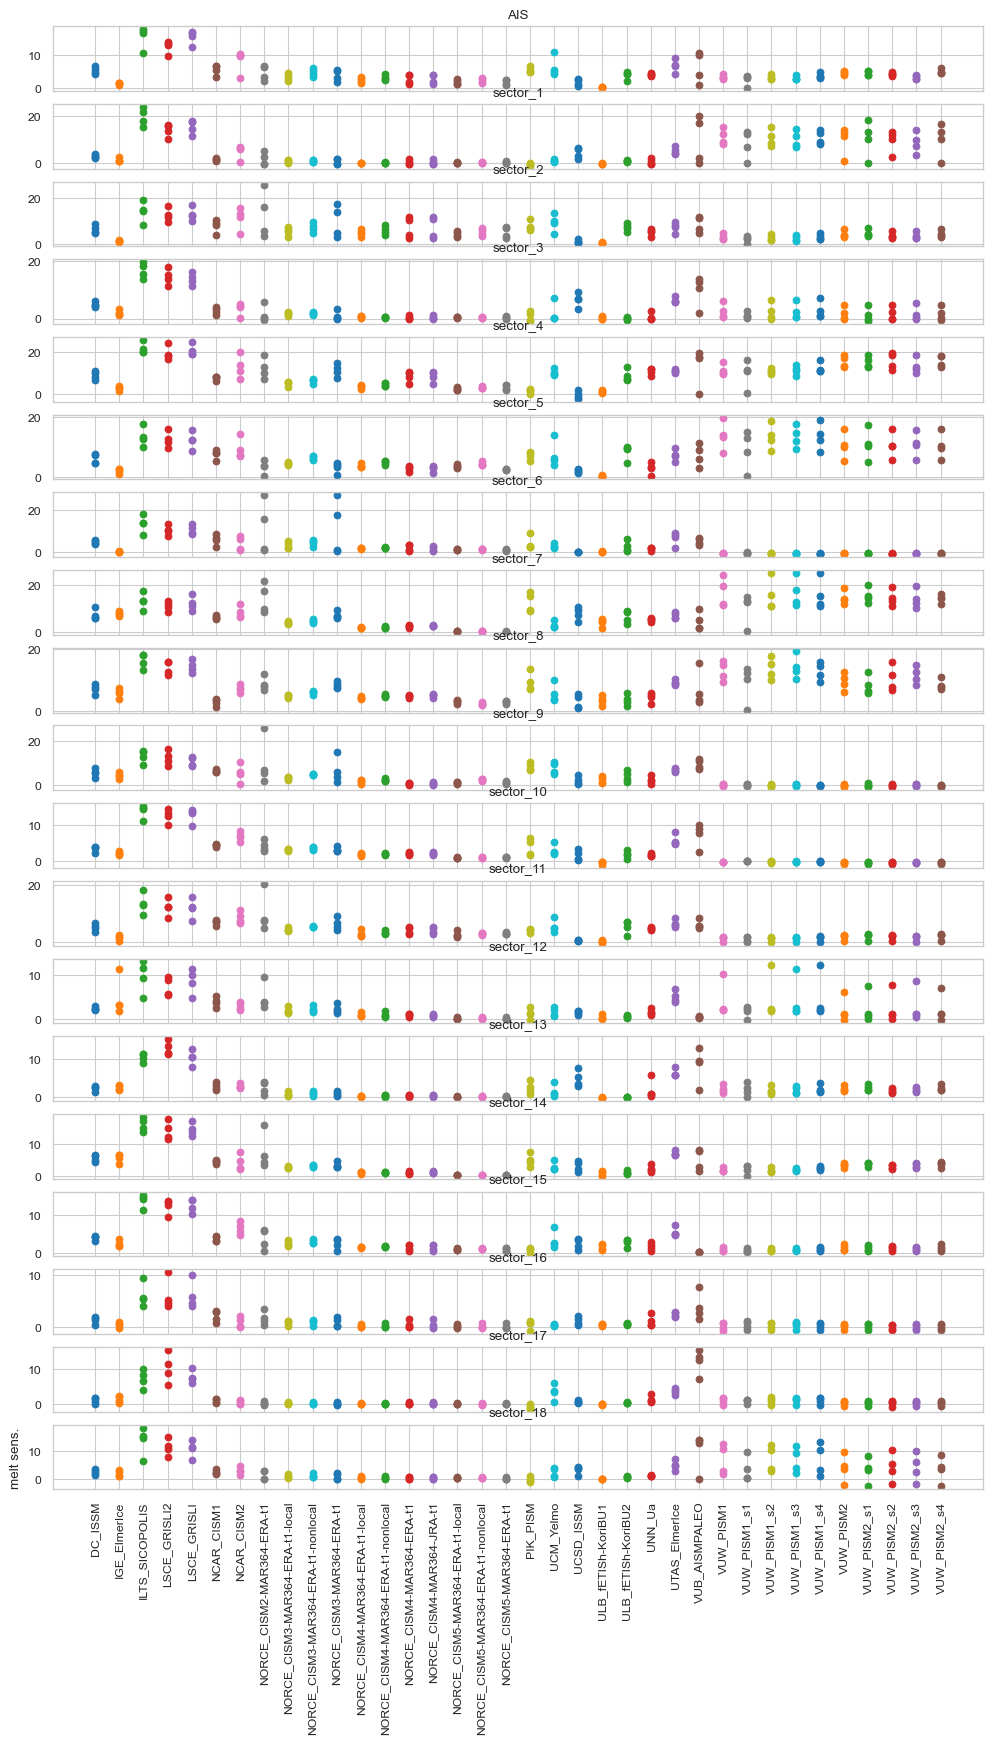

In [10]:
f,ax = plt.subplots(19,1, figsize = (12,19), sharex = True)
for i,Mod in enumerate(Models):
    dfmodel = df_ms[df_ms['Model']== Mod]
    ax[0].scatter([i,i,i,i],dfmodel.AIS.values)
    ax[0].set_xticks(Models.index)
    ax[0].set_title('AIS')
    for j in range(1,19):
        ax[j].scatter([i,i,i,i],dfmodel['sector_'+str(j)].values)
        ax[j].set_title('sector_'+str(j))
        
ax[18].set_xticklabels(Models, rotation=90)
ax[18].set_ylabel('melt sens.')
    
    


### Let us takte the mean with all the four values and check wether the ba

In [11]:
df_ms_mean =  df_ms[df_ms['Experiment']== 'expAE02']
df_ms_mean = df_ms_mean.drop(columns=['Experiment'])
df_ms_mean = df_ms_mean.drop(columns=['Path'])

In [12]:

for i,Mod in enumerate(Models):
    dfmodel = df_ms[df_ms['Model']== Mod]
    df_ms_mean.loc[df_ms_mean['Model'] == Mod, 'AIS'] = dfmodel.AIS.values.mean()

    for j in range(1,19):
        df_ms_mean.loc[df_ms_mean['Model'] == Mod, 'sector_'+str(j)]  =dfmodel['sector_'+str(j)].values.mean()


Text(0.5, 1.0, 'standardized melt sensetiviy ')

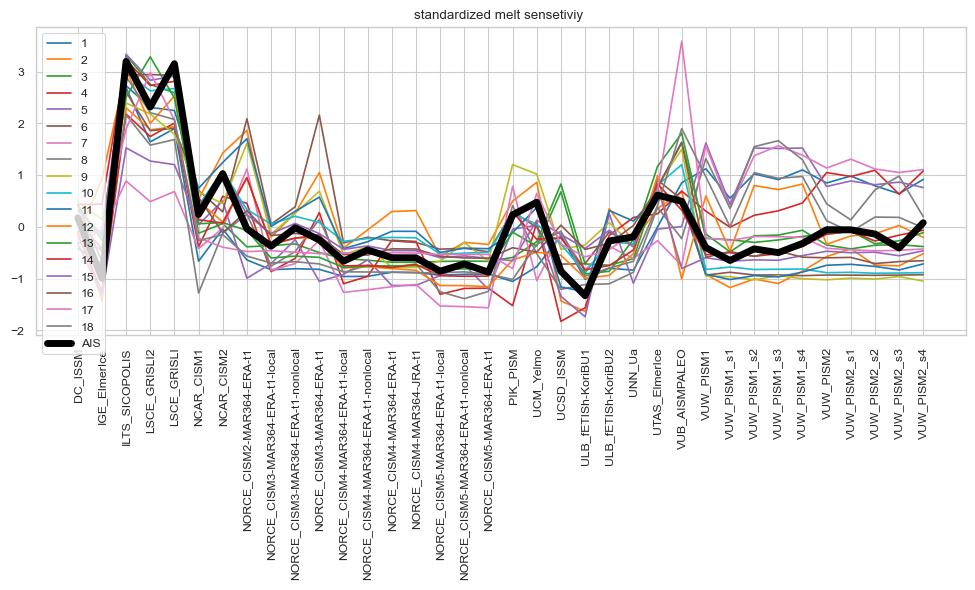

In [13]:
f,ax = plt.subplots(1,1,figsize =( 12,4))

for j in range(1,19):
    y = df_ms_mean['sector_'+str(j)].values
    mnan = np.isnan(y)
    y_m = y[~mnan].mean()
    std = y[~mnan].std()
    y = y -y_m
    y =y/std
    ax.plot(Models.index,y,label = j)
y = df_ms_mean.AIS.values
mnan = np.isnan(y)
y_m = y[~mnan].mean()
std = y[~mnan].std()
y = y -y_m
y =y/std
ax.plot(Models.index,y,lw = '5',label = 'AIS', color = 'black')
ax.set_xticks(Models.index)
        
ax.set_xticklabels(Models, rotation=90)
ax.legend(loc = 2,)
ax.set_title('standardized melt sensetiviy ')

### Standardized melt sensetiviy for AIS reveals most sensetiv modes. Hoever the relativ AIS sensetivitu factor are not always representet as for the same secotrs 1-19. nonethless let us use AIS for melting

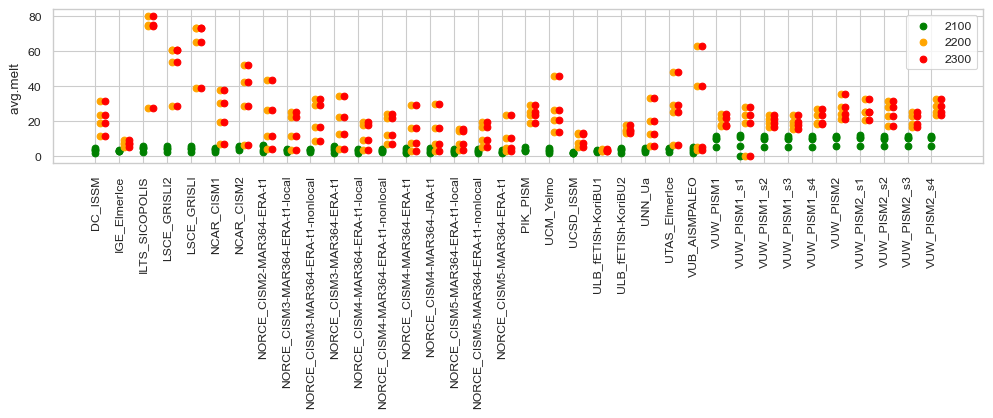

In [175]:
f,ax = plt.subplots(1,1, figsize = (12,2), sharex = True)
for i,Mod in enumerate(Models):
    dftemp = df_m2100
    ax.scatter([i,i,i,i],dftemp [dftemp ['Model']== Mod].AIS.values,color = 'green',label='2100' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
for i,Mod in enumerate(Models):
    dftemp = df_m2300
    it = i+0.2
    ax.scatter([it,it,it,it],dftemp [dftemp ['Model']== Mod].AIS.values ,color = 'orange',label='2200' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
for i,Mod in enumerate(Models):
    dftemp = df_m2300
    it = i+0.4

    ax.scatter([it,it,it,it],dftemp [dftemp ['Model']== Mod].AIS.values, color = 'red',label='2300' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
ax.set_ylabel('avg.melt ')
    
ax.legend()


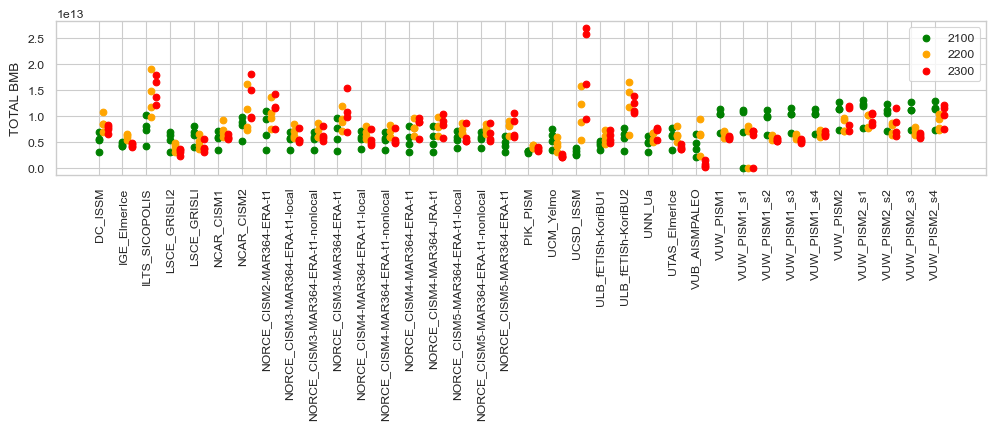

In [180]:
f,ax = plt.subplots(1,1, figsize = (12,2), sharex = True)
for i,Mod in enumerate(Models):
    dftemp = df_bmb2100
    ax.scatter([i,i,i,i],dftemp [dftemp ['Model']== Mod].AIS.values,color = 'green',label='2100' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
for i,Mod in enumerate(Models):
    dftemp = df_bmb2200
    it = i+0.2
    ax.scatter([it,it,it,it],dftemp [dftemp ['Model']== Mod].AIS.values ,color = 'orange',label='2200' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
for i,Mod in enumerate(Models):
    dftemp = df_bmb2300
    it = i+0.4

    ax.scatter([it,it,it,it],dftemp [dftemp ['Model']== Mod].AIS.values, color = 'red',label='2300' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
ax.set_ylabel('TOTAL BMB')
    
ax.legend()

Text(0.5, 0, 'melt sensetivity')

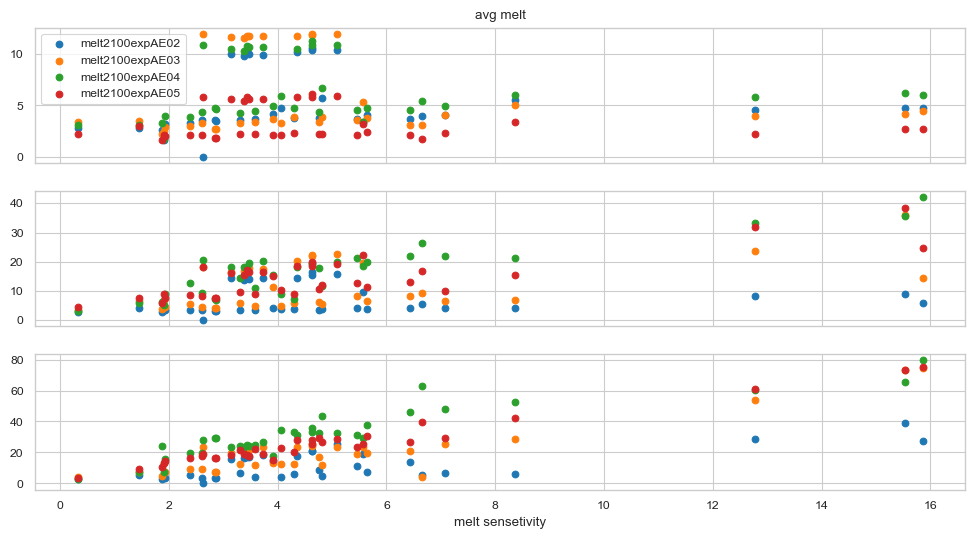

In [176]:
f,ax = plt.subplots(3,1, figsize = (12,6), sharex = True)
i =0
dftemp = df_m2100
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')
ax[0].set_title('avg melt')
i =1 
dftemp = df_m2200
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')

i =2
dftemp = df_m2300
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')
ax[0].legend()
ax[2].set_xlabel("melt sensetivity")

Text(0.5, 0, 'melt sensetivity')

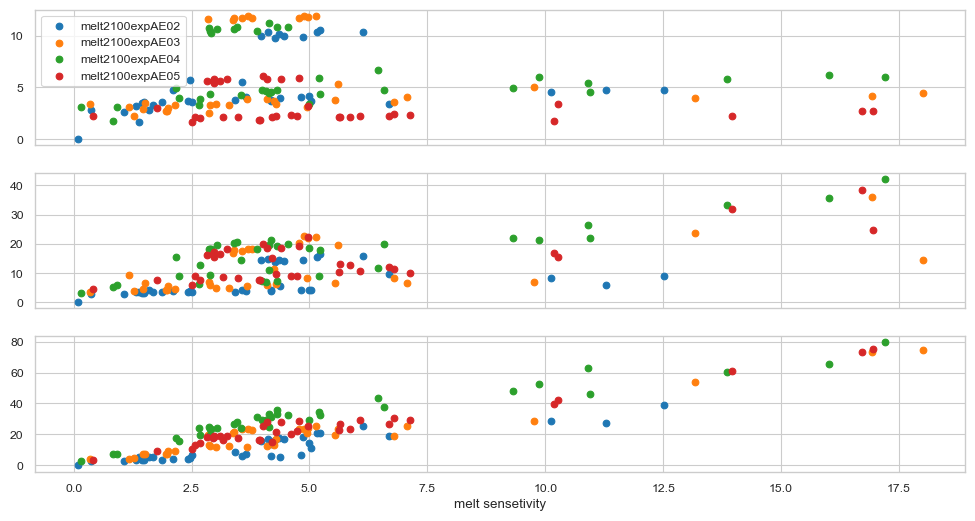

In [191]:
f,ax = plt.subplots(3,1, figsize = (12,6), sharex = True)
i =0
dftemp = df_m2100
exps = ['expAE02','expAE03','expAE04','expAE05']
for exp in exps:
    
    x = df_ms[df_ms['Experiment']== exp].AIS.values
    y =dftemp[dftemp['Experiment' ]== exp].AIS.values
    ax[i].scatter(x,y, label = 'melt2100' + exp)

i =1 
dftemp = df_m2200
for exp in exps:
    
    x = df_ms[df_ms['Experiment']== exp].AIS.values
    y =dftemp[dftemp['Experiment' ]== exp].AIS.values
    ax[i].scatter(x,y, label = 'melt2100' + exp)


i =2
dftemp = df_m2300
for exp in exps:
    
    x = df_ms[df_ms['Experiment']== exp].AIS.values
    y =dftemp[dftemp['Experiment' ]== exp].AIS.values
    ax[i].scatter(x,y, label = 'melt2100' + exp)

ax[0].legend()
ax[2].set_xlabel("melt sensetivity")

Text(0.5, 0, 'melt sensetivity')

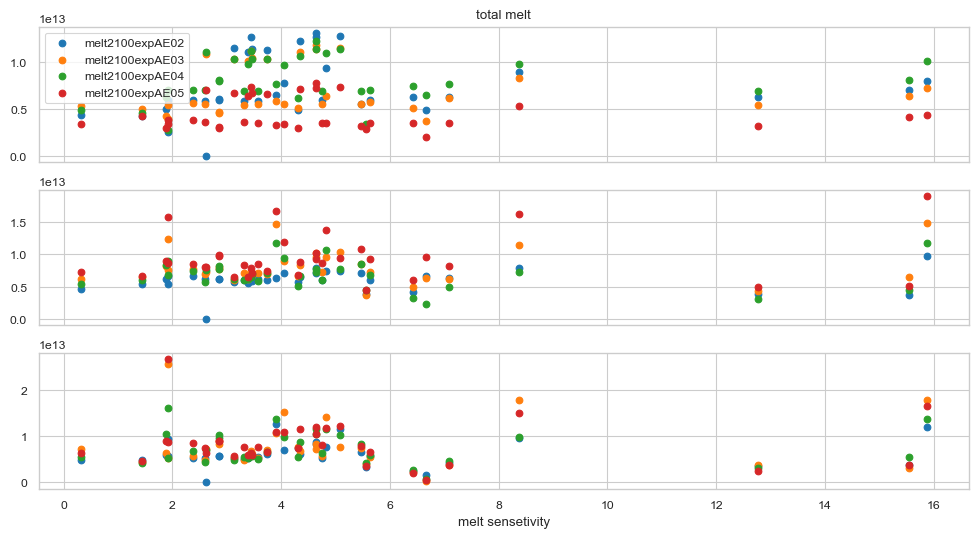

In [177]:
f,ax = plt.subplots(3,1, figsize = (12,6), sharex = True)
i =0
dftemp = df_bmb2100
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')
ax[0].set_title('total melt')
i =1 
dftemp = df_bmb2200
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')

i =2
dftemp = df_bmb2300
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')
ax[0].legend()
ax[2].set_xlabel("melt sensetivity")

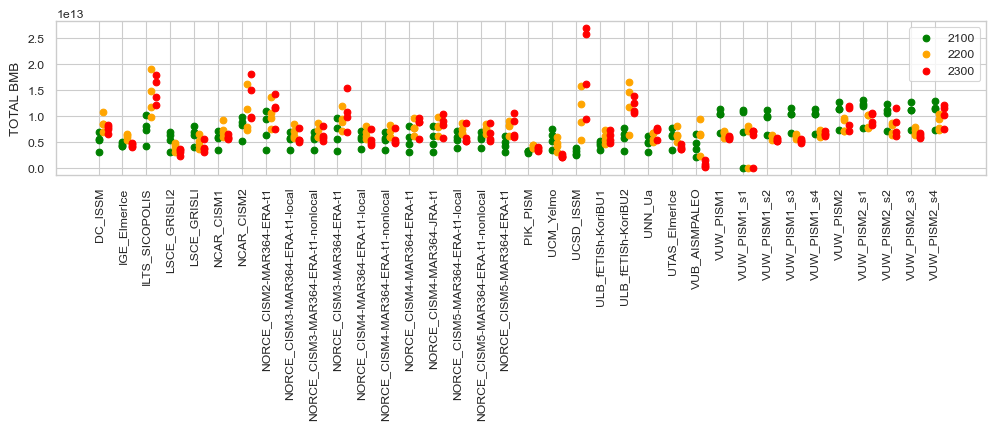

Text(0, 0.5, 'avg.melt 2300.')

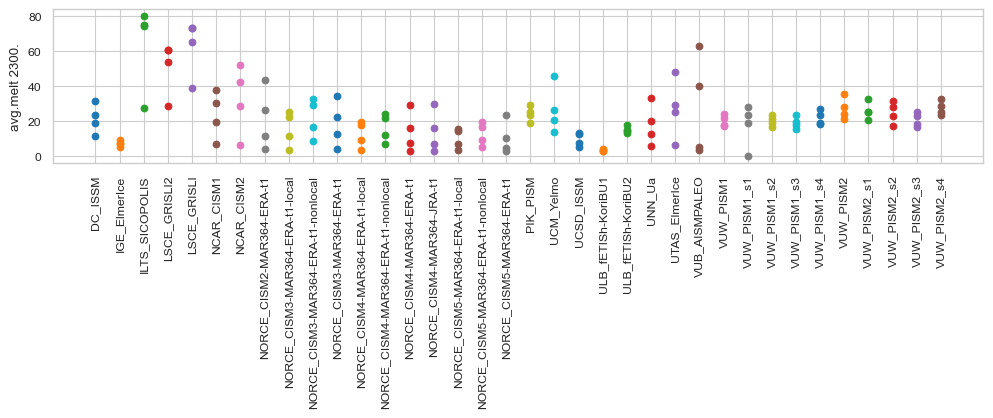

Text(0, 0.5, 'melt sens.')

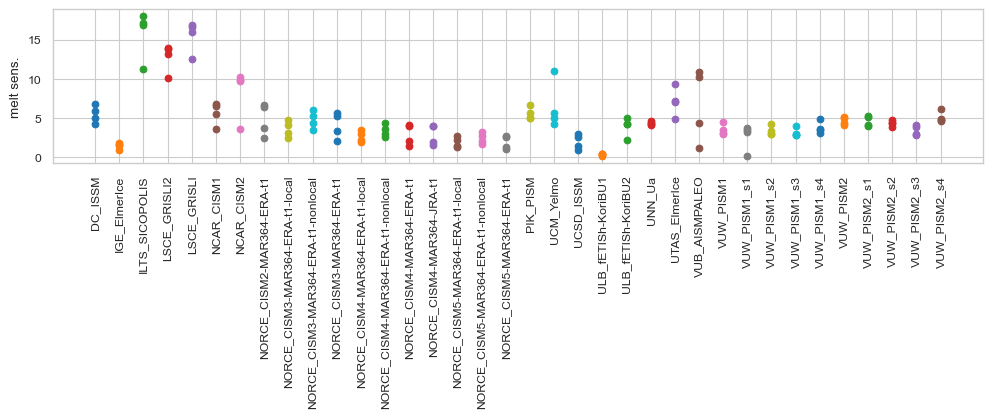

In [126]:
f,ax = plt.subplots(1,1, figsize = (12,2), sharex = True)
for i,Mod in enumerate(Models):
    dftemp = df_m2300
    ax.scatter([i,i,i,i],dftemp [dftemp ['Model']== Mod].AIS.values)
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
ax.set_ylabel('avg.melt 2300.')
    

Text(0, 0.5, 'melt sens.')

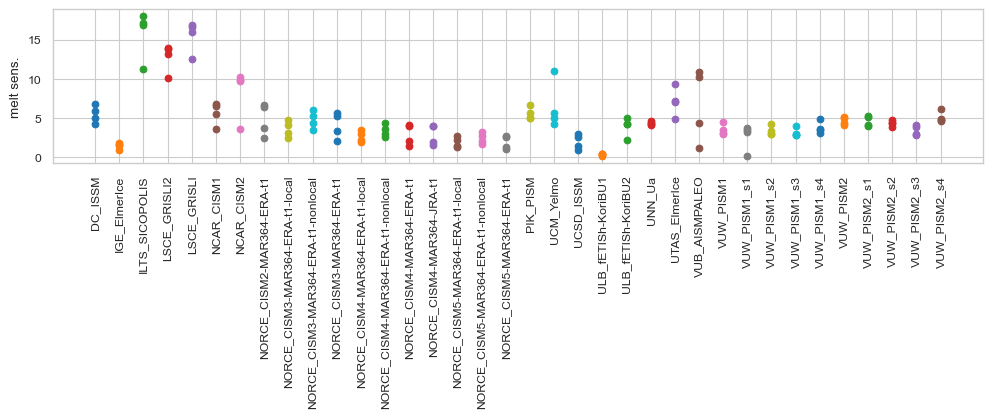

In [127]:
f,ax = plt.subplots(1,1, figsize = (12,2), sharex = True)
for i,Mod in enumerate(Models):
    ax.scatter([i,i,i,i],df_ms[df_bmb2200['Model']== Mod].AIS.values)
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
ax.set_ylabel('melt sens.')
    